In [1]:
import numpy as np
from sens_heat import SensHeat as Sens
sens = Sens() 
x = np.full(sens.n1*sens.n2, 0.3) # 設計変数を領域全体で0.3に設定
f, gradf = sens.compute_obj_sens(x)

In [2]:
import numpy as np
from sens_heat import SubsetTemp as Sens
sens = Sens() 
x = np.full(sens.n1*sens.n2, 0.3) # 設計変数を領域全体で0.3に設定
f, gradf = sens.compute_obj_sens(x)

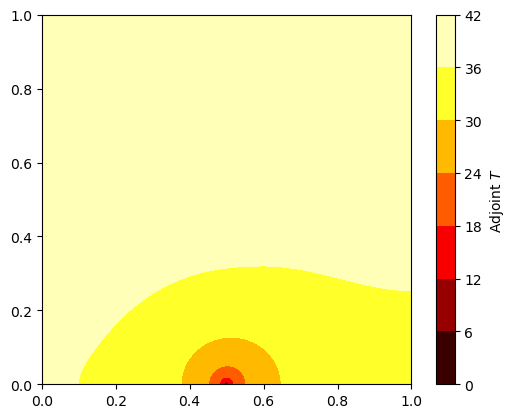

In [3]:
import matplotlib.pyplot as plt
x_p, y_p = np.linspace(0, sens.L1, sens.n1+1), np.linspace(0, sens.L2, sens.n2+1)
X, Y = np.meshgrid(x_p, y_p)
plt.contourf(X, Y, sens.adj_d.reshape((sens.n2+1, sens.n1+1)), cmap='hot')
plt.gca().set_aspect('equal')
plt.colorbar(label=r'$\mathrm{Adjoint}$ $T$')
plt.gca().set_aspect('equal')

In [4]:
%load_ext autoreload
%autoreload 
import numpy as np
v_max = 0.3
flag_heat = 0
if flag_heat==0: # 0: SensHeat, others: SubsetTemp
    from sens_heat import SensHeat as Sens
else:
    from sens_heat import SubsetTemp as Sens
sens = Sens()
x = np.full(sens.n1*sens.n2, v_max)
f, gradf = sens.compute_obj_sens(x)

In [5]:
s_px, s_py = 50, 1 # A:(50,1); B:(50,50); C:(99,99)
s_point = s_px + sens.n1*(s_py - 1) - 1
eps = 1e-5

In [6]:
#前進差分
c = x[s_point]
x_ep = x.copy()
x_ep[s_point] = c + eps
f_ep, _ = sens.compute_obj_sens(x_ep)
c_ep = x_ep[s_point]
s = gradf
f_fd = (f_ep - f) / (c_ep - c)
print("随伴法　:", s[s_point])
print("有限差分:", f_fd)
print("相対誤差:", np.abs(s[s_point]-f_fd)/np.abs(f_fd))   

随伴法　: -518.58665486972
有限差分: -518.574771484218
相対誤差: 2.2915471703238982e-05


In [7]:
#複素微分
from scipy import sparse
from scipy.sparse import linalg as spla
eps_complex = 1e-15
xc = v_max*np.ones_like(x, dtype='complex')
ec = np.zeros_like(x, dtype='complex')
ec[s_point] = complex(0, eps_complex)
xc = xc + ec
sK = (sens.Ke.flatten()[:, None]*(sens.k0+(sens.k-sens.k0)*xc**sens.p)).flatten('F')
K = sparse.coo_matrix((sK, (sens.iK, sens.jK))).tocsc()
uc = np.zeros((sens.n1+1)*(sens.n2+1), dtype='complex')
uc[sens.free] = spla.spsolve(K[sens.free][:, sens.free], sens.f[sens.free])
if flag_heat==0:
    cc = np.dot(sens.f, uc)
else:
    cc = np.dot(sens.f_obj, uc)
fc = cc.imag/eps_complex
print("随伴法　:", s[s_point])
print("複素微分:", fc)
print("相対誤差:", np.abs(s[s_point]-fc)/np.abs(fc))

随伴法　: -518.58665486972
複素微分: -518.5866548692051
相対誤差: 9.928672155496578e-13
